In [9]:
import sys, os
sys.path.append(os.path.abspath("src"))
#from src.utils.utils_import import *

import numpy as np
import pandas as pd

from src.data.dataloader import *

import matplotlib.pyplot as plt


In [10]:
df_image = get_image_data()
df_caption = get_caption_dataset(df_image)

# Introduction


explanation of the conteset

Who can participate? 
One entry per person, e-mail address, or Instagram account. Anyone age thirteen or over can enter, except employees, agents, or representatives of Sponsor or any other party associated with the development or administration of the Contest, or any member of their immediate family.

Submit: Every week the readers can enter a caption of 250 characters or less for a new cartoon either on the webpage (https://www.newyorker.com/cartoons/contest) or on instagram (@newyorkermag) using the hashtag #MyNewYorkerCaption. 

Rate: Rate the funniness of the captions from the previous week.

Vote: select the winning caption by voting on three finalists from the week prior

Winner:

sources: https://www.newyorker.com/cartoons/contest
https://www.newyorker.com/about/caption-contest-rules



In [11]:
df_image

,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198
...,...,...,...,...,...,...,...,...,...,...,...
379,891,NaN,NaN,NaN,NaN,NaN,NaN,"“Sorry, only the catcher works from home.”",NaN,2023-08-21,928856
380,892,NaN,NaN,NaN,NaN,NaN,NaN,"“Yes, it's called Thesaurus, but you're not re...",NaN,2023-08-28,788251
381,893,NaN,NaN,NaN,NaN,NaN,NaN,“The seller isn't willing to come down.”,NaN,2023-09-04,1085745
382,894,NaN,NaN,NaN,NaN,NaN,NaN,“See how the nose seems to follow you?”,NaN,2023-09-11,878676


In [12]:
df_image.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   contest_id                  384 non-null    int64         
 1   num_captions                240 non-null    float64       
 2   image_locations             240 non-null    object        
 3   image_descriptions          240 non-null    object        
 4   image_uncanny_descriptions  240 non-null    object        
 5   entities                    240 non-null    object        
 6   questions                   240 non-null    object        
 7   Top Rated caption           384 non-null    object        
 8   The New Yorker's winner     216 non-null    object        
 9   date                        384 non-null    datetime64[ns]
 10  Number of votes             384 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memo

In [13]:
# creation of a function that returns the image and the the first x comments

# variables to change from user
NUMBER_OF_COMMENTS = 5
CONTEST = 514

#df_image[df_image['contest_id'] == CONTEST]
contest_information = df_image.loc[(df_image['contest_id'] == CONTEST)]

print(f"number of captions: {contest_information.num_captions}")
print(f"date : {contest_information.date}")
print("additional information")
print(f"image location: {contest_information.image_locations}")
print(f"image description: {contest_information.image_descriptions}")
print(f"uncanny desriptions: {contest_information.image_uncanny_descriptions}")
#print(f"top rated caption {Number of votes}")
contest_information

number of captions: 4    3951.0
Name: num_captions, dtype: float64
date : 4   2016-04-03
Name: date, dtype: datetime64[ns]
additional information
image location: 4    [plains]
Name: image_locations, dtype: object
image description: 4    [Some cowboys are riding through the desert. T...
Name: image_descriptions, dtype: object
uncanny desriptions: 4    [There are rocking horses in place of real hor...
Name: image_uncanny_descriptions, dtype: object


,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198


In [14]:
captions = df_caption.loc[(df_caption['contest_id'] == CONTEST)]

captions.loc[(captions['rank'] < NUMBER_OF_COMMENTS)].drop(['contest_id', 'date', 'mean', 'precision'], axis=1)


,rank,caption,votes,not_funny,somewhat_funny,funny
15770,0,"No, you grow up",186,64,69,53
15771,1,"Sheriff, I feel like we're just going through ...",172,50,86,36
15772,2,We're losing them! They're gaining on us! We'r...,140,53,47,40
15773,3,Sometimes I feel like we're just going through...,150,47,71,32
15774,4,I think they're toying with us.,135,48,55,32


# General analysis


In [23]:
def linear_model(x, slope, intercept):
    return slope * x + intercept

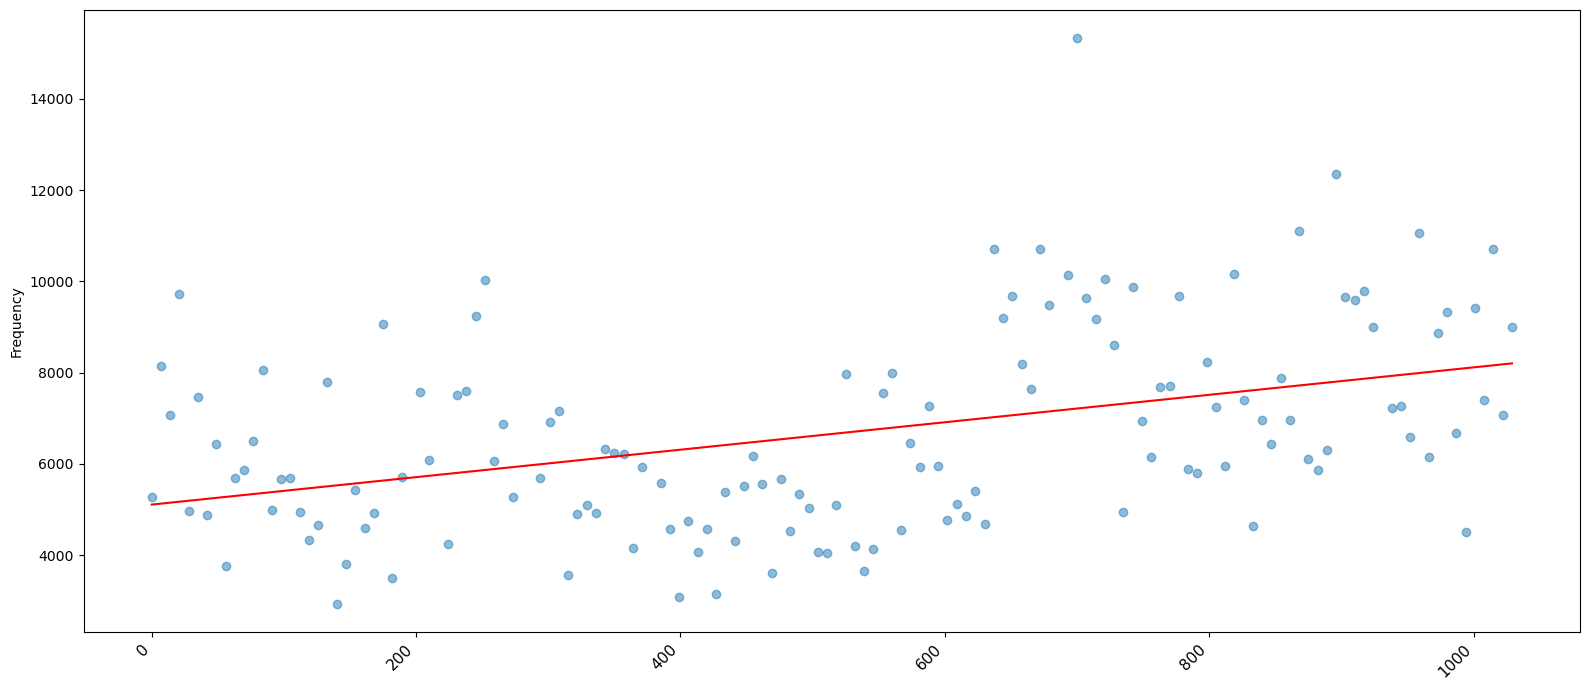

In [ ]:
# Fit a linear function (1st degree polynomial)

from scipy.optimize import curve_fit


# Convert date to a different format (using days since a specific date)
df_image['date_numeric'] = (df_image['date'] - df_image['date'].min()).dt.total_seconds() / (24 * 3600) 
df_image = df_image.dropna()  # Drop any missing values

# Fit the model to your data
popt, pcov = curve_fit(linear_model, df_image['date_numeric'], df_image['num_captions'])

# Extract optimal parameters
slope, intercept = popt

fit_line = linear_model(df_image['date_numeric'], slope, intercept)

#df_image['rolling_num_captions'] = df_image['num_captions'].rolling(window=7).mean() #.interpolate(method='linear')

plt.figure(figsize=(16, 7))
plt.scatter(df_image['date_numeric'], df_image.num_captions, alpha=0.5)
plt.plot(df_image['date_numeric'], fit_line, color='red', label='Curve Fit')



plt.xticks(rotation=45, fontsize=11, ha="right")


plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#change x axis :)

In [ ]:
df_image

,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes,rolling_num_captions
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627,NaN
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660,NaN
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120,NaN
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013,NaN
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
379,891,NaN,NaN,NaN,NaN,NaN,NaN,"“Sorry, only the catcher works from home.”",NaN,2023-08-21,928856,NaN
380,892,NaN,NaN,NaN,NaN,NaN,NaN,"“Yes, it's called Thesaurus, but you're not re...",NaN,2023-08-28,788251,NaN
381,893,NaN,NaN,NaN,NaN,NaN,NaN,“The seller isn't willing to come down.”,NaN,2023-09-04,1085745,NaN
382,894,NaN,NaN,NaN,NaN,NaN,NaN,“See how the nose seems to follow you?”,NaN,2023-09-11,878676,NaN
